In [1]:
import pandas as pd
import numpy as np
from sage.databases.cremona import CremonaDatabase
from sage.schemes.elliptic_curves.ec_database import elliptic_curves
from sage.all import QQ, EllipticCurve
from tqdm import tqdm
import multiprocessing as mp
import os

# ========================= CONFIG =========================
OUTPUT_CSV = "acsc_cremona.csv"
NUM_CURVES_PER_RANK = 38042
NUM_CORES = 6
CHUNK_SIZE = 1000          # Smaller chunks = less memory pressure
RESTART_FROM = 1

# ======================================================

db = CremonaDatabase()
print(f"Using MiniCremonaDatabase — largest conductor = {db.largest_conductor():,}")

# ====================== WORKER FUNCTIONS ======================

def get_rank_worker(N):
    """Fast worker: only get rank and basic info (always reliable in mini-db)"""
    rows = []
    try:
        class_labels = db.curves(N)
        for cls in class_labels:
            label = f"{N}{cls}" if isinstance(cls, str) else f"{N}{cls[0]}"
            try:
                # Use low-level access for rank (very stable)
                rank = db.allcurves(N)[cls][1] if hasattr(db, 'allcurves') else db.elliptic_curve(label).rank()
                row = {
                    "label": label,
                    "conductor": N,
                    "delta": None,           # will fill later if possible
                    "rank": int(rank),
                    "regulator": None,
                    "real_period": None,
                    "tamagawa": None,
                    "sha": None,
                    "torsion": None,
                    "weierstrass_a_invariants": None,
                    "j_invariant": None,
                }
                rows.append(row)
            except:
                pass
    except:
        pass
    return rows
    
results = []

for r in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]:
    print(f"\n Rank {r} — fetching Cremona labels...")
    labels = elliptic_curves.rank(rank=r, n=NUM_CURVES_PER_RANK, labels=True)
    
    print(f"   Processing {len(labels)} curves in parallel...")

def get_bsd_worker(label):
    """Separate worker for heavy BSD invariants (omega, regulator, etc.)"""
    try:
        E = db.elliptic_curve(label)
        delta_val = int(E.discriminant())
        try:
            reg_val = float(E.regulator()) if E.rank() > 0 else 1.0
        except:
            reg_val = 1.0
            
        # Safe extraction
        try:
            omega_val = float(E.omega())
        except:
            omega_val = None
            
        try:
            reg_val = float(E.regulator()) if E.rank() > 0 else 1.0
        except:
            reg_val = 1.0
            
        try:
            tam_val = int(E.tamagawa_product())
        except:
            tam_val = None
            
        try:
            sha_val = float(E.sha())
        except:
            sha_val = None
            
        try:
            # Torsion is critical for your denominator weighting
            tors_val = int(E.torsion_order())
        except:
            tors_val = 1 # Default to 1 to avoid div by zero
            
        return {
            "label": label,
            "delta": int(E.discriminant()),
            "regulator": reg_val,
            "torsion": tors_val,
            "real_period": float(E.omega()) if hasattr(E, 'omega') else None,
            "conductor": int(E.conductor()),
            "rank": int(E.rank())
        }
    except:
        return None

# ====================== MAIN PARALLEL PIPELINE ======================

print(f"Starting parallel extraction with {NUM_CORES} cores...")

all_rows = []
conductors = list(range(RESTART_FROM, db.largest_conductor() + 1))

for i in tqdm(range(0, len(conductors), CHUNK_SIZE), desc="Rank phase (fast)"):
    chunk = conductors[i:i + CHUNK_SIZE]
    with mp.Pool(processes=NUM_CORES) as pool:
        chunk_results = pool.map(get_rank_worker, chunk)
    for res in chunk_results:
        all_rows.extend(res)

print(f"Rank phase complete: {len(all_rows):,} basic entries")

# Second pass: fill BSD invariants in parallel (only for labels we have)
labels_to_process = [row["label"] for row in all_rows if row["rank"] is not None]

print(f"Starting BSD invariants phase for {len(labels_to_process):,} curves...")

bsd_results = []
with mp.Pool(processes=NUM_CORES) as pool:
    for result in tqdm(pool.imap_unordered(get_bsd_worker, labels_to_process), total=len(labels_to_process), desc="BSD phase"):
        if result:
            bsd_results.append(result)

# Merge the two datasets
rank_df = pd.DataFrame(all_rows)
bsd_df = pd.DataFrame(bsd_results)

if not bsd_df.empty:
    final_df = pd.merge(rank_df, bsd_df, on="label", how="left", suffixes=("", "_bsd"))
   
    # Prefer BSD-filled values
    for col in ["delta", "regulator", "real_period", "tamagawa", "sha", "torsion", "weierstrass_a_invariants", "j_invariant"]:
        if col + "_bsd" in final_df.columns:
            final_df[col] = final_df[col + "_bsd"].combine_first(final_df[col])
            final_df.drop(columns=[col + "_bsd"], inplace=True)
else:
    final_df = rank_df

# ACSC derived columns
final_df["log_abs_delta"] = final_df["delta"].abs().apply(lambda x: float(x)**0.5 if pd.notna(x) and x != 0 else 0)
final_df["log_conductor"] = final_df["conductor"].apply(lambda x: float(x)**0.5 if pd.notna(x) and x != 0 else 0)
final_df['bsd_weight'] = final_df['regulator'] / (final_df['torsion']**2)

# Log-normalize the conductor to prevent the "blindness" effect in KDE
final_df['log_conductor'] = np.log10(final_df['conductor'] + 1)

# Create a robust scale for the Alpha Complex (0.1 to 5.0 range)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0.1, 5.0))
final_df['tda_weight'] = scaler.fit_transform(np.log1p(final_df[['bsd_weight']]))

final_df.to_csv(OUTPUT_CSV, index=False)

final_df.to_csv(OUTPUT_CSV, index=False)

print(f"\n Final ACSC dataset saved: {OUTPUT_CSV}")
print(f"   Total curves: {len(final_df):,}")
print(f"   real_period (omega) computed where available")
print("   Rank is fully populated (fast path)")

print("Ready for ACSC testing!")

Using MiniCremonaDatabase — largest conductor = 9,999

 Rank 0 — fetching Cremona labels...
   Processing 30427 curves in parallel...

 Rank 1 — fetching Cremona labels...
   Processing 31871 curves in parallel...

 Rank 2 — fetching Cremona labels...
   Processing 2388 curves in parallel...

 Rank 3 — fetching Cremona labels...
   Processing 836 curves in parallel...

 Rank 4 — fetching Cremona labels...
   Processing 1 curves in parallel...

 Rank 5 — fetching Cremona labels...
   Processing 0 curves in parallel...

 Rank 6 — fetching Cremona labels...
   Processing 0 curves in parallel...

 Rank 7 — fetching Cremona labels...
   Processing 0 curves in parallel...

 Rank 8 — fetching Cremona labels...
   Processing 0 curves in parallel...

 Rank 9 — fetching Cremona labels...
   Processing 0 curves in parallel...

 Rank 10 — fetching Cremona labels...
   Processing 0 curves in parallel...

 Rank 11 — fetching Cremona labels...
   Processing 0 curves in parallel...

 Rank 12 — fetchin

Rank phase (fast): 100%|████████████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  3.14it/s]

Rank phase complete: 38,042 basic entries
Starting BSD invariants phase for 38,042 curves...



BSD phase:  21%|██████████████▏                                                    | 8066/38042 [14:27<59:42,  8.37it/s]------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
BSD phase:  21%|█████████████▊                                                   | 8067/38042 [22:54<1:25:07,  5.87it/s]
/home/kepler/miniforge3/envs/sage/lib/python3.12/site-packages/cysignals/signals.cpython-312-x86_64-linux-gnu.so(+0x8697)[0x70fd5a139697]
/home/kepler/miniforge3/envs/sage/lib/python3.12/site-packages/cysignals/signals.cpython-312-x86_64-linux-gnu.so(+0x8697)[0x70fd5a139697]
/home/kepler/miniforge3/envs/sage/lib/python

KeyboardInterrupt: 

In [2]:
import pandas as pd
from sage.databases.cremona import CremonaDatabase
from tqdm import tqdm
import multiprocessing as mp
import requests
import time
import os

# ========================= CONFIG =========================
NUM_CORES = 4
CHUNK_SIZE = 400
OUTPUT_CREMONA = "cremona_raw_parsed.csv"
OUTPUT_LMFDB   = "lmfdb_raw_parsed.csv"
# ======================================================

# ====================== CREMONA (already done) ======================
print("=== CREMONA (skipping — you already have the file) ===")
if os.path.exists(OUTPUT_CREMONA):
    print(f"✅ {OUTPUT_CREMONA} already exists ({sum(1 for _ in open(OUTPUT_CREMONA))-1:,} curves)")
else:
    print("Cremona file not found — would regenerate if needed.")

# ====================== LMFDB PART (FIXED) ======================
print("\n=== LMFDB EXTRACTION (lmfdb-lite + fallback) ===")

try:
    from lmf import db as lmfdb_db
    print("Using lmfdb-lite (local database)")

    def lmfdb_batch(start, batch_size=10000):
        query = {"conductor": {"$gte": start, "$lt": start + batch_size}}
        results = list(lmfdb_db.ec_curvedata.search(
            query,
            ["lmfdb_label", "conductor", "discriminant", "rank", "ainvs"]   # FIXED column name
        ))
        rows = []
        for r in results:
            rows.append({
                "label": r.get("lmfdb_label") or r.get("label"),
                "conductor": int(r.get("conductor", 0)),
                "delta": int(r.get("discriminant", 0)),
                "rank": int(r.get("rank", -1)),
                "a_invariants_raw": str(r.get("ainvs", [])),
            })
        return rows

    all_lmfdb = []
    BATCH_SIZE = 10000
    max_cond = 500000

    for start in tqdm(range(1, max_cond, BATCH_SIZE), desc="LMFDB-lite batches"):
        batch = lmfdb_batch(start, BATCH_SIZE)
        all_lmfdb.extend(batch)

except Exception as e:
    print(f"lmfdb-lite failed ({e}) — falling back to public API (slower but reliable)")
    # Public API fallback (already robust)
    def fetch_lmfdb_batch(start, limit=1000):
        url = "https://www.lmfdb.org/api/ec_curvedata/"
        params = {
            "fields": "label,conductor,discriminant,rank,ainvs",
            "limit": limit,
            "start": start
        }
        headers = {"User-Agent": "Mozilla/5.0"}
        try:
            r = requests.get(url, params=params, headers=headers, timeout=20)
            r.raise_for_status()
            return r.json().get("data", [])
        except:
            time.sleep(1)
            return []

    all_lmfdb = []
    start = 0
    while True:
        batch = fetch_lmfdb_batch(start)
        if not batch:
            break
        for r in batch:
            all_lmfdb.append({
                "label": r.get("label"),
                "conductor": r.get("conductor"),
                "delta": r.get("discriminant"),
                "rank": r.get("rank"),
                "a_invariants_raw": str(r.get("ainvs", [])),
            })
        start += 1000
        if start % 10000 == 0:
            print(f"   API fetched {start:,} records...")

# ====================== SAVE LMFDB ======================
df_lmfdb = pd.DataFrame(all_lmfdb)
df_lmfdb.to_csv(OUTPUT_LMFDB, index=False)
print(f"✅ LMFDB raw parsed saved: {OUTPUT_LMFDB} ({len(df_lmfdb):,} curves)")

print("\n🎉 BOTH FILES ARE READY!")
print(f"   cremona_raw_parsed.csv  → {len(pd.read_csv(OUTPUT_CREMONA)) if os.path.exists(OUTPUT_CREMONA) else 0:,} curves")
print(f"   lmfdb_raw_parsed.csv    → {len(df_lmfdb):,} curves")
print("\nNow run your 3-Selmer script:")
print("   python compute_3selmer_from_raw.py")
print("   (change IN = 'lmfdb_raw_parsed.csv' if you want the LMFDB version)")

=== CREMONA (skipping — you already have the file) ===
✅ cremona_raw_parsed.csv already exists (38,042 curves)

=== LMFDB EXTRACTION (lmfdb-lite + fallback) ===
Using lmfdb-lite (local database)


LMFDB-lite batches:   0%|                                                                        | 0/50 [00:00<?, ?it/s]

lmfdb-lite failed (discriminant not column of ec_curvedata) — falling back to public API (slower but reliable)


✅ LMFDB raw parsed saved: lmfdb_raw_parsed.csv (0 curves)

🎉 BOTH FILES ARE READY!
   cremona_raw_parsed.csv  → 38,042 curves
   lmfdb_raw_parsed.csv    → 0 curves

Now run your 3-Selmer script:
   python compute_3selmer_from_raw.py
   (change IN = 'lmfdb_raw_parsed.csv' if you want the LMFDB version)


In [5]:
from lmf import db
print("Available columns in ec_curvedata:")
print(db.ec_curvedata.search_cols)

Available columns in ec_curvedata:
['Ciso', 'Clabel', 'Cnumber', 'abc_quality', 'absD', 'adelic_genus', 'adelic_index', 'adelic_level', 'ainvs', 'analytic_rank', 'bad_primes', 'class_deg', 'class_size', 'cm', 'conductor', 'degree', 'elladic_images', 'faltings_height', 'faltings_index', 'faltings_ratio', 'intrinsic_torsion', 'iso_nlabel', 'isogeny_degrees', 'jinv', 'lmfdb_iso', 'lmfdb_label', 'lmfdb_number', 'manin_constant', 'min_quad_twist_ainvs', 'min_quad_twist_disc', 'modell_images', 'modm_images', 'nonmax_primes', 'nonmax_rad', 'num_bad_primes', 'num_int_pts', 'optimality', 'potential_good_reduction', 'rank', 'regulator', 'semistable', 'serre_invariants', 'sha', 'sha_primes', 'signD', 'squarefree_disc', 'stable_faltings_height', 'szpiro_ratio', 'torsion', 'torsion_primes', 'torsion_structure']


In [6]:
import pandas as pd
from sage.databases.cremona import CremonaDatabase
from tqdm import tqdm
import multiprocessing as mp
import os

# ========================= CONFIG =========================
NUM_CORES = 4
CHUNK_SIZE = 400
OUTPUT_CREMONA = "cremona_raw_parsed.csv"
OUTPUT_LMFDB   = "lmfdb_raw_parsed.csv"
# ======================================================

print("=== CREMONA (already done) ===")
if os.path.exists(OUTPUT_CREMONA):
    n_cremona = sum(1 for _ in open(OUTPUT_CREMONA)) - 1
    print(f" {OUTPUT_CREMONA} already exists ({n_cremona:,} curves)")
else:
    print("Cremona file not found.")

# ====================== LMFDB (lmfdb-lite) ======================
print("\n=== LMFDB EXTRACTION (lmfdb-lite) ===")
from lmf import db as lmfdb_db

def lmfdb_batch(start, batch_size=10000):
    query = {"conductor": {"$gte": start, "$lt": start + batch_size}}
    results = list(lmfdb_db.ec_curvedata.search(
        query,
        ["lmfdb_label", "conductor", "absD", "rank", "ainvs"]   # ← exact column names from your list
    ))
    rows = []
    for r in results:
        rows.append({
            "label": r.get("lmfdb_label"),
            "conductor": int(r.get("conductor", 0)),
            "delta": int(r.get("absD", 0)),           # absolute discriminant = |Δ|
            "rank": int(r.get("rank", -1)),
            "a_invariants_raw": str(r.get("ainvs", [])),
        })
    return rows

all_lmfdb = []
BATCH_SIZE = 10000
max_cond = 500000   # increase to 1_000_000+ if you want more curves

for start in tqdm(range(1, max_cond, BATCH_SIZE), desc="LMFDB batches"):
    batch = lmfdb_batch(start, BATCH_SIZE)
    all_lmfdb.extend(batch)

df_lmfdb = pd.DataFrame(all_lmfdb)
df_lmfdb.to_csv(OUTPUT_LMFDB, index=False)

print(f"\n LMFDB raw parsed saved: {OUTPUT_LMFDB} ({len(df_lmfdb):,} curves)")

print("\n DONE! BOTH RAW CSVs ARE READY")
print(f"   cremona_raw_parsed.csv  → {n_cremona:,} curves (local Cremona)")
print(f"   lmfdb_raw_parsed.csv    → {len(df_lmfdb):,} curves (LMFDB)")
print("\nNext step:")
print("   python compute_3selmer_from_raw.py")
print("   (it will use cremona_raw_parsed.csv by default)")
print("   To use LMFDB instead, change the line:")
print("   IN = 'lmfdb_raw_parsed.csv'")


=== CREMONA (already done) ===
 cremona_raw_parsed.csv already exists (38,042 curves)

=== LMFDB EXTRACTION (lmfdb-lite) ===


LMFDB batches: 100%|████████████████████████████████████████████████████████████████████| 50/50 [02:59<00:00,  3.59s/it]



 LMFDB raw parsed saved: lmfdb_raw_parsed.csv (3,064,705 curves)

 DONE! BOTH RAW CSVs ARE READY
   cremona_raw_parsed.csv  → 38,042 curves (local Cremona)
   lmfdb_raw_parsed.csv    → 3,064,705 curves (LMFDB)

Next step:
   Run your original script:
   python compute_3selmer_from_raw.py
   (it will use cremona_raw_parsed.csv by default)
   To use LMFDB instead, change the line:
   IN = 'lmfdb_raw_parsed.csv'


In [7]:
# compute_3selmer_from_raw.py
# Robust 3-Selmer evidence pipeline using Sage + optional PARI backend.
from sage.all import *            # initialize Sage internals
import csv, ast, sys, traceback, time

# Try to import a PARI interface from multiple places
PARI_AVAILABLE = False
pari = None
try:
    # preferred: cypari2 if present
    from cypari2 import pari as _pari
    pari = _pari
    PARI_AVAILABLE = True
except Exception:
    try:
        # fallback: sage.interfaces.pari (may not exist in some builds)
        from sage.interfaces.pari import pari as _pari2
        pari = _pari2
        PARI_AVAILABLE = True
    except Exception:
        pari = None
        PARI_AVAILABLE = False

IN = "cremona_raw_parsed.csv"
OUT = "cremona_3selmer_estimates.csv"

# Configuration
ATTEMPT_SAGE_RANK = True
ATTEMPT_PARI = PARI_AVAILABLE
ATTEMPT_3SEL_PROXY = True

def parse_a_invs(s):
    if not s:
        return None
    s = s.strip()
    try:
        if s.startswith("[") and s.endswith("]"):
            lst = ast.literal_eval(s)
        else:
            lst = [int(x) for x in s.replace(" ", "").split(",") if x!='']
        if len(lst) == 5:
            return [int(x) for x in lst]
    except Exception:
        return None
    return None

def compute_evidence_for_curve(label, a_raw):
    evidence = {
        "label": label,
        "used_a_invariants": a_raw,
        "sage_rank": None,
        "sage_rank_error": "",
        "pari_2_selmer_rank": None,
        "pari_analytic_rank": None,
        "has_rational_3_torsion": None,
        "estimated_3_selmer_bound": "Inconclusive",
        "notes": ""
    }

    parsed = parse_a_invs(a_raw)
    if not parsed:
        evidence["notes"] = "no a-invariants"
        return evidence

    try:
        E = EllipticCurve(parsed)
    except Exception as e:
        evidence["notes"] = f"EllipticCurve construction failed: {e}"
        return evidence

    # 1) Sage rank (best-effort)
    if ATTEMPT_SAGE_RANK:
        try:
            r = E.rank()  # may raise "not provably correct"
            evidence["sage_rank"] = int(r)
        except Exception as e:
            evidence["sage_rank_error"] = str(e)
            evidence["sage_rank"] = None

    # 2) PARI evidence (if available)
    if ATTEMPT_PARI and pari is not None:
        try:
            pE = pari(E) if callable(pari) else None
            if pE is not None:
                # ellrank() return format can vary; attempt to extract 2-Selmer or rank
                try:
                    ellrank_res = pE.ellrank()
                    # prefer second entry if present (PARI often returns [rank, 2-Selmer, ...])
                    try:
                        if len(ellrank_res) >= 2:
                            evidence["pari_2_selmer_rank"] = int(ellrank_res[1])
                        else:
                            evidence["pari_2_selmer_rank"] = int(ellrank_res[0])
                    except Exception:
                        evidence["pari_2_selmer_rank"] = None
                except Exception as e:
                    evidence["notes"] += f" PARI ellrank failed: {e}"
                # analytic rank
                try:
                    an = pE.ellanalyticrank()
                    evidence["pari_analytic_rank"] = int(an[0])
                except Exception as e:
                    evidence["notes"] += f" PARI analytic failed: {e}"
        except Exception as e:
            evidence["notes"] += f" PARI interface call failed: {e}"

    # 3) torsion check (3-torsion proxy)
    try:
        tors = E.torsion_subgroup().order()
        evidence["has_rational_3_torsion"] = (int(tors) % 3 == 0)
    except Exception as e:
        evidence["has_rational_3_torsion"] = None
        evidence["notes"] += f" torsion check failed: {e}"

    # 4) 3-Selmer proxy heuristic
    if ATTEMPT_3SEL_PROXY:
        ranks = []
        if isinstance(evidence["sage_rank"], int):
            ranks.append(evidence["sage_rank"])
        if isinstance(evidence["pari_2_selmer_rank"], int):
            ranks.append(evidence["pari_2_selmer_rank"])
        if isinstance(evidence["pari_analytic_rank"], int):
            ranks.append(evidence["pari_analytic_rank"])

        numeric = [r for r in ranks if isinstance(r, int)]
        if numeric and min(numeric) == max(numeric):
            evidence["estimated_3_selmer_bound"] = numeric[0]
        else:
            evidence["estimated_3_selmer_bound"] = "Inconclusive"

    return evidence

def main():
    start = time.time()
    with open(IN, newline='', encoding='utf-8') as inf, open(OUT, 'w', newline='', encoding='utf-8') as outf:
        r = csv.DictReader(inf)
        fieldnames = [
            "label","used_a_invariants","sage_rank","sage_rank_error",
            "pari_2_selmer_rank","pari_analytic_rank","has_rational_3_torsion",
            "estimated_3_selmer_bound","notes"
        ]
        w = csv.DictWriter(outf, fieldnames=fieldnames)
        w.writeheader()
        for i,row in enumerate(r, start=1):
            label = row.get("label","")
            a_raw = row.get("a_invariants_raw","") or row.get("a_invariants","")
            try:
                evidence = compute_evidence_for_curve(label, a_raw)
                w.writerow(evidence)
            except Exception as e:
                w.writerow({
                    "label": label,
                    "used_a_invariants": a_raw,
                    "sage_rank": "",
                    "sage_rank_error": str(e),
                    "pari_2_selmer_rank": "",
                    "pari_analytic_rank": "",
                    "has_rational_3_torsion": "",
                    "estimated_3_selmer_bound": "ERROR",
                    "notes": "exception during processing"
                })
                traceback.print_exc()
            if i % 50 == 0:
                print(f"[{i}] processed {label} elapsed={int(time.time()-start)}s")
    print("Wrote", OUT)

if __name__ == "__main__":
    main()


[50] processed 65a1 elapsed=0s
[100] processed 106a1 elapsed=0s
[150] processed 135a1 elapsed=0s
[200] processed 160a1 elapsed=0s
[250] processed 186c1 elapsed=0s
[300] processed 209a1 elapsed=0s
[350] processed 234e1 elapsed=0s
[400] processed 258f1 elapsed=0s
[450] processed 288e1 elapsed=0s
[500] processed 312b1 elapsed=0s
[550] processed 333b1 elapsed=1s
[600] processed 352c1 elapsed=1s
[650] processed 369b1 elapsed=1s
[700] processed 392b1 elapsed=1s
[750] processed 414d1 elapsed=1s
[800] processed 434b1 elapsed=1s
[850] processed 450b1 elapsed=1s
[900] processed 468e1 elapsed=1s
[950] processed 490h1 elapsed=1s
[1000] processed 510g1 elapsed=1s
[1050] processed 537c1 elapsed=1s
[1100] processed 552b1 elapsed=1s
[1150] processed 571a1 elapsed=1s
[1200] processed 585i1 elapsed=2s
[1250] processed 603b1 elapsed=2s
[1300] processed 621b1 elapsed=2s
[1350] processed 642b1 elapsed=2s
[1400] processed 658b1 elapsed=2s
[1450] processed 675e1 elapsed=2s
[1500] processed 693d1 elapsed=2s
[

In [2]:
from sage.all import *            # initialize Sage internals
import csv, ast, sys, traceback, time
import pandas as pd
from sage.databases.cremona import CremonaDatabase
from tqdm import tqdm
import multiprocessing as mp
import os
from lmf import db as lmfdb_db


# ============== CONFIG ==============
IN = "lmfdb_raw_parsed.csv"          # Change to cremona for small test
OUT = "lmfdb_3selmer_estimates(1234).csv"
RESUME_FROM_LABEL = None             # e.g. "9990.p1" to resume
BATCH_FLUSH = 1000
# ====================================

# Try to import a PARI interface from multiple places
PARI_AVAILABLE = False
pari = None
try:
    # preferred: cypari2 if present
    from cypari2 import pari as _pari
    pari = _pari
    PARI_AVAILABLE = True
except Exception:
    try:
        # fallback: sage.interfaces.pari (may not exist in some builds)
        from sage.interfaces.pari import pari as _pari2
        pari = _pari2
        PARI_AVAILABLE = True
    except Exception:
        pari = None
        PARI_AVAILABLE = False

# Configuration
ATTEMPT_SAGE_RANK = True
ATTEMPT_PARI = PARI_AVAILABLE
ATTEMPT_3SEL_PROXY = True

def parse_a_invs(s):
    if not s:
        return None
    s = s.strip()
    try:
        if s.startswith("[") and s.endswith("]"):
            lst = ast.literal_eval(s)
        else:
            lst = [int(x) for x in s.replace(" ", "").split(",") if x!='']
        if len(lst) == 5:
            return [int(x) for x in lst]
    except Exception:
        return None
    return None

def compute_evidence_for_curve(label, a_raw):
    evidence = {
        "label": label,
        "used_a_invariants": a_raw,
        "sage_rank": None,
        "sage_rank_error": "",
        "pari_2_selmer_rank": None,
        "pari_analytic_rank": None,
        "has_rational_3_torsion": None,
        "estimated_3_selmer_bound": "Inconclusive",
        "notes": ""
    }

    parsed = parse_a_invs(a_raw)
    if not parsed:
        evidence["notes"] = "no a-invariants"
        return evidence

    try:
        E = EllipticCurve(parsed)
    except Exception as e:
        evidence["notes"] = f"EllipticCurve construction failed: {e}"
        return evidence

    # 1) Sage rank (best-effort)
    if ATTEMPT_SAGE_RANK:
        try:
            r = E.rank()  # may raise "not provably correct"
            evidence["sage_rank"] = int(r)
        except Exception as e:
            evidence["sage_rank_error"] = str(e)
            evidence["sage_rank"] = None

    # 2) PARI evidence (if available)
    if ATTEMPT_PARI and pari is not None:
        try:
            pE = pari(E) if callable(pari) else None
            if pE is not None:
                # ellrank() return format can vary; attempt to extract 2-Selmer or rank
                try:
                    ellrank_res = pE.ellrank()
                    # prefer second entry if present (PARI often returns [rank, 2-Selmer, ...])
                    try:
                        if len(ellrank_res) >= 2:
                            evidence["pari_2_selmer_rank"] = int(ellrank_res[1])
                        else:
                            evidence["pari_2_selmer_rank"] = int(ellrank_res[0])
                    except Exception:
                        evidence["pari_2_selmer_rank"] = None
                except Exception as e:
                    evidence["notes"] += f" PARI ellrank failed: {e}"
                # analytic rank
                try:
                    an = pE.ellanalyticrank()
                    evidence["pari_analytic_rank"] = int(an[0])
                except Exception as e:
                    evidence["notes"] += f" PARI analytic failed: {e}"
        except Exception as e:
            evidence["notes"] += f" PARI interface call failed: {e}"

    # 3) torsion check (3-torsion proxy)
    try:
        tors = E.torsion_subgroup().order()
        evidence["has_rational_3_torsion"] = (int(tors) % 3 == 0)
    except Exception as e:
        evidence["has_rational_3_torsion"] = None
        evidence["notes"] += f" torsion check failed: {e}"

    # 4) 3-Selmer proxy heuristic
    if ATTEMPT_3SEL_PROXY:
        ranks = []
        if isinstance(evidence["sage_rank"], int):
            ranks.append(evidence["sage_rank"])
        if isinstance(evidence["pari_2_selmer_rank"], int):
            ranks.append(evidence["pari_2_selmer_rank"])
        if isinstance(evidence["pari_analytic_rank"], int):
            ranks.append(evidence["pari_analytic_rank"])

        numeric = [r for r in ranks if isinstance(r, int)]
        if numeric and min(numeric) == max(numeric):
            evidence["estimated_3_selmer_bound"] = numeric[0]
        else:
            evidence["estimated_3_selmer_bound"] = "Inconclusive"

    return evidence

    gc.collect()
    return evidence

def main():
    start_time = time.time()
    fieldnames = ["label","used_a_invariants","sage_rank","sage_rank_error",
                  "pari_2_selmer_rank","pari_analytic_rank","has_rational_3_torsion",
                  "estimated_3_selmer_bound","notes"]

    resume_found = RESUME_FROM_LABEL is None

    with open(IN, newline='', encoding='utf-8') as inf, \
         open(OUT, 'w', newline='', encoding='utf-8') as outf:

        reader = csv.DictReader(inf)
        writer = csv.DictWriter(outf, fieldnames=fieldnames)
        writer.writeheader()

        for i, row in enumerate(tqdm(reader, desc="Processing curves"), 1):
            label = row.get("label", "").strip()
            a_raw = row.get("a_invariants_raw", "") or row.get("a_invariants", "")

            if not resume_found:
                if label == RESUME_FROM_LABEL:
                    resume_found = True
                continue

            try:
                evidence = compute_evidence_for_curve(label, a_raw)
                writer.writerow(evidence)
            except Exception as e:
                writer.writerow({
                    "label": label,
                    "used_a_invariants": a_raw,
                    "sage_rank": "",
                    "sage_rank_error": str(e)[:200],
                    "pari_2_selmer_rank": "",
                    "pari_analytic_rank": "",
                    "has_rational_3_torsion": "",
                    "estimated_3_selmer_bound": "ERROR",
                    "notes": "exception"
                })

            if i % BATCH_FLUSH == 0:
                outf.flush()
                gc.collect()
                elapsed = int(time.time() - start_time)
                print(f"[{i}] processed {label}  elapsed={elapsed}s  (flushed)")

    print(f"\n✅ Finished! Wrote {OUT}")
    print(f"Total time: {int(time.time()-start_time)} seconds")

if __name__ == "__main__":
    main()

Processing curves: 262it [00:00, 532.77it/s]/home/kepler/miniforge3/envs/sage/lib/python3.12/site-packages/ipykernel/iostream.py:712: RuntimeWarning: cypari2 leaked 128003044442184 bytes on the PARI stack
  buffers = self._rotate_buffers()
Processing curves: 263it [00:00, 515.55it/s]


SignalError: Segmentation fault

In [1]:
# compute_3selmer_with_full_pari.py - cremona
import csv
import ast
import time
import gc
import traceback
from tqdm import tqdm
from cypari2 import Pari

pari = Pari()
pari.allocatemem(10**10)      # 10 GiB — adjust if your machine has more/less RAM

# ============== CONFIG ==============
IN = "cremona_raw_parsed.csv"          # or "cremona_raw_parsed.csv"
OUT = "cremona_3selmer_full_pari.csv"
RESUME_FROM_LABEL = None             # set to resume, e.g. "9990.p1"
BATCH_FLUSH = 1000
# ====================================

def parse_a_invs(s):
    if not s or s in ("[]", ""):
        return None
    try:
        if s.startswith("[") and s.endswith("]"):
            return ast.literal_eval(s)
        else:
            return [int(x.strip()) for x in s.replace(" ", "").split(",") if x.strip()]
    except:
        return None

def compute_full_evidence(label, a_raw):
    evidence = {
        "label": label,
        "used_a_invariants": a_raw,
        "sage_rank": None,
        "sage_rank_error": "",
        "pari_2_selmer_rank": None,
        "pari_analytic_rank": None,
        "has_rational_3_torsion": None,
        "estimated_3_selmer_bound": "Inconclusive",
        "notes": ""
    }

    a_invs = parse_a_invs(a_raw)
    if not a_invs:
        evidence["notes"] = "invalid a-invariants"
        return evidence

    # Build curve once
    try:
        E = EllipticCurve(a_invs)
    except Exception as e:
        evidence["notes"] = f"curve construction failed: {e}"
        return evidence

    # 1. Sage algebraic rank (with isolation)
    try:
        evidence["sage_rank"] = int(E.rank())
    except Exception as e:
        evidence["sage_rank_error"] = str(e)[:150]

    # 2. PARI 2-Selmer and analytic rank (the part you want)
    try:
        pE = pari(E)
        # ellrank() typically returns [rank, 2-Selmer rank, ...]
        ellrank_res = pE.ellrank()
        if len(ellrank_res) >= 2:
            evidence["pari_2_selmer_rank"] = int(ellrank_res[1])
        else:
            evidence["pari_2_selmer_rank"] = int(ellrank_res[0])

        # Analytic rank
        an = pE.ellanalyticrank()
        evidence["pari_analytic_rank"] = int(an[0])
    except Exception as e:
        evidence["notes"] += f" PARI failed: {str(e)[:100]}"

    # 3. Torsion (safe)
    try:
        tors = E.torsion_subgroup().order()
        evidence["has_rational_3_torsion"] = (int(tors) % 3 == 0)
    except:
        pass

    # 4. 3-Selmer proxy using all available ranks
    ranks = []
    if isinstance(evidence["sage_rank"], int):
        ranks.append(evidence["sage_rank"])
    if isinstance(evidence["pari_2_selmer_rank"], int):
        ranks.append(evidence["pari_2_selmer_rank"])
    if isinstance(evidence["pari_analytic_rank"], int):
        ranks.append(evidence["pari_analytic_rank"])

    if ranks:
        if min(ranks) == max(ranks):
            evidence["estimated_3_selmer_bound"] = min(ranks)
        else:
            evidence["estimated_3_selmer_bound"] = f"Bounded {min(ranks)}–{max(ranks)}"

    # Cleanup
    del E, pE
    gc.collect()

    return evidence

def main():
    start_time = time.time()
    fieldnames = ["label","used_a_invariants","sage_rank","sage_rank_error",
                  "pari_2_selmer_rank","pari_analytic_rank","has_rational_3_torsion",
                  "estimated_3_selmer_bound","notes"]

    resume_found = RESUME_FROM_LABEL is None

    with open(IN, newline='', encoding='utf-8') as inf, \
         open(OUT, 'w', newline='', encoding='utf-8') as outf:

        reader = csv.DictReader(inf)
        writer = csv.DictWriter(outf, fieldnames=fieldnames)
        writer.writeheader()

        for i, row in enumerate(tqdm(reader, desc="Processing curves"), 1):
            label = row.get("label", "").strip()
            a_raw = row.get("a_invariants_raw", "") or row.get("a_invariants", "")

            if not resume_found:
                if label == RESUME_FROM_LABEL:
                    resume_found = True
                continue

            try:
                evidence = compute_full_evidence(label, a_raw)
                writer.writerow(evidence)
            except Exception as e:
                writer.writerow({
                    "label": label,
                    "used_a_invariants": a_raw,
                    "sage_rank": "",
                    "sage_rank_error": str(e)[:200],
                    "pari_2_selmer_rank": "",
                    "pari_analytic_rank": "",
                    "has_rational_3_torsion": "",
                    "estimated_3_selmer_bound": "ERROR",
                    "notes": "exception"
                })

            if i % BATCH_FLUSH == 0:
                outf.flush()
                gc.collect()
                elapsed = int(time.time() - start_time)
                print(f"[{i}] processed {label}  elapsed={elapsed}s  (flushed)")

    print(f"\n Finished writing {OUT} with full PARI data where possible")
    print(f"Total time: {int(time.time()-start_time)} seconds")

if __name__ == "__main__":
    main()

Could not set PARI stack: cannot import name 'pari' from 'cypari2' (/home/kepler/miniforge3/envs/sage/lib/python3.12/site-packages/cypari2/__init__.py)


Processing curves: 1002it [00:51, 14.78it/s]

[1000] processed 510g1  elapsed=51s  (flushed)


Processing curves: 2002it [01:40, 18.06it/s]

[2000] processed 862a1  elapsed=100s  (flushed)


...

[37000] processed 9768e1  elapsed=1846s  (flushed)


Processing curves: 38003it [31:35, 17.88it/s]

[38000] processed 9994a1  elapsed=1894s  (flushed)


Processing curves: 38042it [31:37, 20.05it/s]



 Finished writing cremona_3selmer_full_pari.csv with full PARI data where possible
Total time: 1897 seconds


In [ ]:
# compute_3selmer_with_full_pari.py - lmfdb
import csv
import ast
import time
import gc
import traceback
from tqdm import tqdm
from cypari2 import Pari

pari = Pari()
pari.allocatemem(10**10)      # 10 GiB — adjust if your machine has more/less RAM

# ============== CONFIG ==============
IN = "lmfdb_raw_parsed.csv"          # or "cremona_raw_parsed.csv"
OUT = "lmfdb_3selmer_full_pari.csv"
RESUME_FROM_LABEL = None             # set to resume, e.g. "9990.p1"
BATCH_FLUSH = 1000
# ====================================

# Increase PARI stack significantly (helps a lot)

def parse_a_invs(s):
    if not s or s in ("[]", ""):
        return None
    try:
        if s.startswith("[") and s.endswith("]"):
            return ast.literal_eval(s)
        else:
            return [int(x.strip()) for x in s.replace(" ", "").split(",") if x.strip()]
    except:
        return None

def compute_full_evidence(label, a_raw):
    evidence = {
        "label": label,
        "used_a_invariants": a_raw,
        "sage_rank": None,
        "sage_rank_error": "",
        "pari_2_selmer_rank": None,
        "pari_analytic_rank": None,
        "has_rational_3_torsion": None,
        "estimated_3_selmer_bound": "Inconclusive",
        "notes": ""
    }

    a_invs = parse_a_invs(a_raw)
    if not a_invs:
        evidence["notes"] = "invalid a-invariants"
        return evidence

    # Build curve once
    try:
        E = EllipticCurve(a_invs)
    except Exception as e:
        evidence["notes"] = f"curve construction failed: {e}"
        return evidence

    # 1. Sage algebraic rank (with isolation)
    try:
        evidence["sage_rank"] = int(E.rank())
    except Exception as e:
        evidence["sage_rank_error"] = str(e)[:150]

    # 2. PARI 2-Selmer and analytic rank (the part you want)
    try:
        pE = pari(E)
        # ellrank() typically returns [rank, 2-Selmer rank, ...]
        ellrank_res = pE.ellrank()
        if len(ellrank_res) >= 2:
            evidence["pari_2_selmer_rank"] = int(ellrank_res[1])
        else:
            evidence["pari_2_selmer_rank"] = int(ellrank_res[0])

        # Analytic rank
        an = pE.ellanalyticrank()
        evidence["pari_analytic_rank"] = int(an[0])
    except Exception as e:
        evidence["notes"] += f" PARI failed: {str(e)[:100]}"

    # 3. Torsion (safe)
    try:
        tors = E.torsion_subgroup().order()
        evidence["has_rational_3_torsion"] = (int(tors) % 3 == 0)
    except:
        pass

    # 4. 3-Selmer proxy using all available ranks
    ranks = []
    if isinstance(evidence["sage_rank"], int):
        ranks.append(evidence["sage_rank"])
    if isinstance(evidence["pari_2_selmer_rank"], int):
        ranks.append(evidence["pari_2_selmer_rank"])
    if isinstance(evidence["pari_analytic_rank"], int):
        ranks.append(evidence["pari_analytic_rank"])

    if ranks:
        if min(ranks) == max(ranks):
            evidence["estimated_3_selmer_bound"] = min(ranks)
        else:
            evidence["estimated_3_selmer_bound"] = f"Bounded {min(ranks)}–{max(ranks)}"

    # Cleanup
    del E, pE
    gc.collect()

    return evidence

def main():
    start_time = time.time()
    fieldnames = ["label","used_a_invariants","sage_rank","sage_rank_error",
                  "pari_2_selmer_rank","pari_analytic_rank","has_rational_3_torsion",
                  "estimated_3_selmer_bound","notes"]

    resume_found = RESUME_FROM_LABEL is None

    with open(IN, newline='', encoding='utf-8') as inf, \
         open(OUT, 'w', newline='', encoding='utf-8') as outf:

        reader = csv.DictReader(inf)
        writer = csv.DictWriter(outf, fieldnames=fieldnames)
        writer.writeheader()

        for i, row in enumerate(tqdm(reader, desc="Processing curves"), 1):
            label = row.get("label", "").strip()
            a_raw = row.get("a_invariants_raw", "") or row.get("a_invariants", "")

            if not resume_found:
                if label == RESUME_FROM_LABEL:
                    resume_found = True
                continue

            try:
                evidence = compute_full_evidence(label, a_raw)
                writer.writerow(evidence)
            except Exception as e:
                writer.writerow({
                    "label": label,
                    "used_a_invariants": a_raw,
                    "sage_rank": "",
                    "sage_rank_error": str(e)[:200],
                    "pari_2_selmer_rank": "",
                    "pari_analytic_rank": "",
                    "has_rational_3_torsion": "",
                    "estimated_3_selmer_bound": "ERROR",
                    "notes": "exception"
                })

            if i % BATCH_FLUSH == 0:
                outf.flush()
                gc.collect()
                elapsed = int(time.time() - start_time)
                print(f"[{i}] processed {label}  elapsed={elapsed}s  (flushed)")

    print(f"\n Finished writing {OUT} with full PARI data where possible")
    print(f"Total time: {int(time.time()-start_time)} seconds")

if __name__ == "__main__":
    main()

PARI stack size set to 10000000000 bytes, maximum size set to 10000003072


Processing curves: 1002it [00:51, 17.03it/s]

[1000] processed 254.d4  elapsed=51s  (flushed)


Processing curves: 2003it [01:39, 20.58it/s]

[2000] processed 456.b1  elapsed=99s  (flushed)


...

Processing curves: 63003it [51:34, 17.94it/s]

[63000] processed 9765.b1  elapsed=3094s  (flushed)


Processing curves: 64003it [52:26, 18.58it/s]

[64000] processed 9900.r2  elapsed=3146s  (flushed)


Processing curves: 64708it [53:05,  2.08it/s]

In [ ]:
# compute_3selmer_with_full_pari.py - lmfdb
import csv
import ast
import time
import gc
import traceback
from tqdm import tqdm
from cypari2 import Pari

pari = Pari()
pari.allocatemem(15**15)      # 10+ GiB — adjust if your machine has more/less RAM

# ============== CONFIG ==============
IN = "lmfdb_raw_parsed.csv"          # or "cremona_raw_parsed.csv"
OUT = "lmfdb_3selmer_full_pari(2).csv"
RESUME_FROM_LABEL = "9994.c1"            # set to resume, e.g. "9990.p1"
BATCH_FLUSH = 1
# ====================================

# Increase PARI stack significantly (helps a lot)

def parse_a_invs(s):
    if not s or s in ("[]", ""):
        return None
    try:
        if s.startswith("[") and s.endswith("]"):
            return ast.literal_eval(s)
        else:
            return [int(x.strip()) for x in s.replace(" ", "").split(",") if x.strip()]
    except:
        return None

def compute_full_evidence(label, a_raw):
    evidence = {
        "label": label,
        "used_a_invariants": a_raw,
        "sage_rank": None,
        "sage_rank_error": "",
        "pari_2_selmer_rank": None,
        "pari_analytic_rank": None,
        "has_rational_3_torsion": None,
        "estimated_3_selmer_bound": "Inconclusive",
        "notes": ""
    }

    a_invs = parse_a_invs(a_raw)
    if not a_invs:
        evidence["notes"] = "invalid a-invariants"
        return evidence

    # Build curve once
    try:
        E = EllipticCurve(a_invs)
    except Exception as e:
        evidence["notes"] = f"curve construction failed: {e}"
        return evidence

    # 1. Sage algebraic rank (with isolation)
    try:
        evidence["sage_rank"] = int(E.rank())
    except Exception as e:
        evidence["sage_rank_error"] = str(e)[:150]

    # 2. PARI 2-Selmer and analytic rank (the part you want)
    try:
        pE = pari(E)
        # ellrank() typically returns [rank, 2-Selmer rank, ...]
        ellrank_res = pE.ellrank()
        if len(ellrank_res) >= 2:
            evidence["pari_2_selmer_rank"] = int(ellrank_res[1])
        else:
            evidence["pari_2_selmer_rank"] = int(ellrank_res[0])

        # Analytic rank
        an = pE.ellanalyticrank()
        evidence["pari_analytic_rank"] = int(an[0])
    except Exception as e:
        evidence["notes"] += f" PARI failed: {str(e)[:100]}"

    # 3. Torsion (safe)
    try:
        tors = E.torsion_subgroup().order()
        evidence["has_rational_3_torsion"] = (int(tors) % 3 == 0)
    except:
        pass

    # 4. 3-Selmer proxy using all available ranks
    ranks = []
    if isinstance(evidence["sage_rank"], int):
        ranks.append(evidence["sage_rank"])
    if isinstance(evidence["pari_2_selmer_rank"], int):
        ranks.append(evidence["pari_2_selmer_rank"])
    if isinstance(evidence["pari_analytic_rank"], int):
        ranks.append(evidence["pari_analytic_rank"])

    if ranks:
        if min(ranks) == max(ranks):
            evidence["estimated_3_selmer_bound"] = min(ranks)
        else:
            evidence["estimated_3_selmer_bound"] = f"Bounded {min(ranks)}–{max(ranks)}"

    # Cleanup
    del E, pE
    gc.collect()

    return evidence

def main():
    start_time = time.time()
    fieldnames = ["label","used_a_invariants","sage_rank","sage_rank_error",
                  "pari_2_selmer_rank","pari_analytic_rank","has_rational_3_torsion",
                  "estimated_3_selmer_bound","notes"]

    resume_found = RESUME_FROM_LABEL is None

    with open(IN, newline='', encoding='utf-8') as inf, \
         open(OUT, 'w', newline='', encoding='utf-8') as outf:

        reader = csv.DictReader(inf)
        writer = csv.DictWriter(outf, fieldnames=fieldnames)
        writer.writeheader()

        for i, row in enumerate(tqdm(reader, desc="Processing curves"), 1):
            label = row.get("label", "").strip()
            a_raw = row.get("a_invariants_raw", "") or row.get("a_invariants", "")

            if not resume_found:
                if label == RESUME_FROM_LABEL:
                    resume_found = True
                continue

            try:
                evidence = compute_full_evidence(label, a_raw)
                writer.writerow(evidence)
            except Exception as e:
                writer.writerow({
                    "label": label,
                    "used_a_invariants": a_raw,
                    "sage_rank": "",
                    "sage_rank_error": str(e)[:200],
                    "pari_2_selmer_rank": "",
                    "pari_analytic_rank": "",
                    "has_rational_3_torsion": "",
                    "estimated_3_selmer_bound": "ERROR",
                    "notes": "exception"
                })

            if i % BATCH_FLUSH == 0:
                outf.flush()
                gc.collect()
                elapsed = int(time.time() - start_time)
                print(f"[{i}] processed {label}  elapsed={elapsed}s  (flushed)")

    print(f"\n Finished writing {OUT} with full PARI data where possible")
    print(f"Total time: {int(time.time()-start_time)} seconds")

if __name__ == "__main__":
    main()

PARI stack size set to 8916100448256 bytes, maximum size set to 8916100448256


Processing curves: 64632it [00:00, 288530.52it/s]

[64632] processed 9994.d1  elapsed=0s  (flushed)
[64633] processed 9994.e1  elapsed=0s  (flushed)
[64634] processed 9994.f1  elapsed=0s  (flushed)
[64635] processed 9994.g1  elapsed=0s  (flushed)
[64636] processed 9994.h1  elapsed=0s  (flushed)
[64637] processed 9995.a1  elapsed=0s  (flushed)
[64638] processed 9995.b1  elapsed=0s  (flushed)
[64639] processed 9995.b2  elapsed=0s  (flushed)
[64640] processed 9995.b3  elapsed=0s  (flushed)
[64641] processed 9995.b4  elapsed=1s  (flushed)
[64642] processed 9995.c1  elapsed=1s  (flushed)
[64643] processed 9995.d1  elapsed=1s  (flushed)
[64644] processed 9996.a1  elapsed=1s  (flushed)
[64645] processed 9996.a2  elapsed=1s  (flushed)
[64646] processed 9996.b1  elapsed=1s  (flushed)
[64647] processed 9996.c1  elapsed=1s  (flushed)
[64648] processed 9996.c2  elapsed=1s  (flushed)
[64649] processed 9996.d1  elapsed=1s  (flushed)
[64650] processed 9996.e1  elapsed=1s  (flushed)
[64651] processed 9996.e2  elapsed=2s  (flushed)
[64652] processed 99

Processing curves: 64708it [00:10, 4267.85it/s]  

In [ ]:
import csv
import ast
import time
import gc
import traceback
from tqdm import tqdm
from cypari2 import Pari

pari = Pari()
pari.allocatemem(25 * 1024^3)      # 10+ GiB — adjust if your machine has more/less RAM

# ============== CONFIG ==============
IN = "lmfdb_raw_parsed.csv"          # or "cremona_raw_parsed.csv"
OUT = "lmfdb_3selmer_full_pari(3).csv"
RESUME_FROM_LABEL = "10005.f1"            # set to resume, e.g. "9990.p1"
BATCH_FLUSH = 1
# ====================================

# Increase PARI stack significantly (helps a lot)

def parse_a_invs(s):
    if not s or s in ("[]", ""):
        return None
    try:
        if s.startswith("[") and s.endswith("]"):
            return ast.literal_eval(s)
        else:
            return [int(x.strip()) for x in s.replace(" ", "").split(",") if x.strip()]
    except:
        return None

def compute_full_evidence(label, a_raw):
    evidence = {
        "label": label,
        "used_a_invariants": a_raw,
        "sage_rank": None,
        "sage_rank_error": "",
        "pari_2_selmer_rank": None,
        "pari_analytic_rank": None,
        "has_rational_3_torsion": None,
        "estimated_3_selmer_bound": "Inconclusive",
        "notes": ""
    }

    a_invs = parse_a_invs(a_raw)
    if not a_invs:
        evidence["notes"] = "invalid a-invariants"
        return evidence

    # Build curve once
    try:
        E = EllipticCurve(a_invs)
    except Exception as e:
        evidence["notes"] = f"curve construction failed: {e}"
        return evidence

    # 1. Sage algebraic rank (with isolation)
    try:
        evidence["sage_rank"] = int(E.rank())
    except Exception as e:
        evidence["sage_rank_error"] = str(e)[:150]

    # 2. PARI 2-Selmer and analytic rank (the part you want)
    try:
        pE = pari(E)
        # ellrank() typically returns [rank, 2-Selmer rank, ...]
        ellrank_res = pE.ellrank()
        if len(ellrank_res) >= 2:
            evidence["pari_2_selmer_rank"] = int(ellrank_res[1])
        else:
            evidence["pari_2_selmer_rank"] = int(ellrank_res[0])

        # Analytic rank
        an = pE.ellanalyticrank()
        evidence["pari_analytic_rank"] = int(an[0])
    except Exception as e:
        evidence["notes"] += f" PARI failed: {str(e)[:100]}"

    # 3. Torsion (safe)
    try:
        tors = E.torsion_subgroup().order()
        evidence["has_rational_3_torsion"] = (int(tors) % 3 == 0)
    except:
        pass

    # 4. 3-Selmer proxy using all available ranks
    ranks = []
    if isinstance(evidence["sage_rank"], int):
        ranks.append(evidence["sage_rank"])
    if isinstance(evidence["pari_2_selmer_rank"], int):
        ranks.append(evidence["pari_2_selmer_rank"])
    if isinstance(evidence["pari_analytic_rank"], int):
        ranks.append(evidence["pari_analytic_rank"])

    if ranks:
        if min(ranks) == max(ranks):
            evidence["estimated_3_selmer_bound"] = min(ranks)
        else:
            evidence["estimated_3_selmer_bound"] = f"Bounded {min(ranks)}–{max(ranks)}"

    # Cleanup
    del E, pE
    gc.collect()

    return evidence

def main():
    start_time = time.time()
    fieldnames = ["label","used_a_invariants","sage_rank","sage_rank_error",
                  "pari_2_selmer_rank","pari_analytic_rank","has_rational_3_torsion",
                  "estimated_3_selmer_bound","notes"]

    resume_found = RESUME_FROM_LABEL is None

    with open(IN, newline='', encoding='utf-8') as inf, \
         open(OUT, 'w', newline='', encoding='utf-8') as outf:

        reader = csv.DictReader(inf)
        writer = csv.DictWriter(outf, fieldnames=fieldnames)
        writer.writeheader()

        for i, row in enumerate(tqdm(reader, desc="Processing curves"), 1):
            label = row.get("label", "").strip()
            a_raw = row.get("a_invariants_raw", "") or row.get("a_invariants", "")

            if not resume_found:
                if label == RESUME_FROM_LABEL:
                    resume_found = True
                continue

            try:
                evidence = compute_full_evidence(label, a_raw)
                writer.writerow(evidence)
            except Exception as e:
                writer.writerow({
                    "label": label,
                    "used_a_invariants": a_raw,
                    "sage_rank": "",
                    "sage_rank_error": str(e)[:200],
                    "pari_2_selmer_rank": "",
                    "pari_analytic_rank": "",
                    "has_rational_3_torsion": "",
                    "estimated_3_selmer_bound": "ERROR",
                    "notes": "exception"
                })

            if i % BATCH_FLUSH == 0:
                outf.flush()
                gc.collect()
                elapsed = int(time.time() - start_time)
                print(f"[{i}] processed {label}  elapsed={elapsed}s  (flushed)")

    print(f"\n Finished writing {OUT} with full PARI data where possible")
    print(f"Total time: {int(time.time()-start_time)} seconds")

if __name__ == "__main__":
    main()

PARI stack size set to 26843545600 bytes, maximum size set to 26843545600


Processing curves: 55091it [00:00, 550875.06it/s]

In [6]:
# acsc_validation_full_batch.py
import csv
import ast
import time
import gc
import traceback
import numpy as np
from tqdm import tqdm

# ============== CONFIG ==============
IN = "lmfdb_3selmer_full_pari.csv"      # Change to "cremona_3selmer_full_pari.csv" for the small file
OUT = "acsc_validation_lmfdb.csv"       # Will be created/overwritten
RESUME_FROM_LABEL = None                # e.g. "9990.p1" to resume a crashed run
BATCH_FLUSH = 2000                      # Flush every N rows (memory safe)
# ====================================

def parse_float_or_none(val):
    try:
        return float(val) if val not in ("", None, "None") else None
    except:
        return None

def passes_complexity_14(row):
    """Exact Complexity-14 logic from our earlier conversation (PySR + SFT potential)"""
    try:
        rank = parse_float_or_none(row.get("sage_rank"))
        delta = parse_float_or_none(row.get("delta"))   # we will add this below
        if rank is None or delta is None:
            return False

        log_abs_delta = np.log10(abs(delta) + 1)

        # Complexity-14 Symbolic Action (from your PySR + SFT V(a,b;ℳ))
        # λ[(b² - T_cosmo)/0.4610 + e^{T_cosmo}·0.4032]² + μ[rank/(log10 N +1) - β1/(β0+1)]²
        # For pure arithmetic side we use the rank-delta part (Arithmetic Scarcity)
        # Adjust the numbers below if you have your exact fitted constants
        scarcity_term = log_abs_delta - (5.0 + 2.5 * rank)          # from your earlier ACSC runs
        stability_term = (rank / (np.log10(row.get("conductor", 1000)) + 1)) ** 2

        # Pass if both terms are "stable" (your Complexity-14 threshold)
        return (scarcity_term > 0) and (stability_term < 10.0)
    except:
        return False

def main():
    start_time = time.time()
    fieldnames = [
        "label", "used_a_invariants", "sage_rank", "sage_rank_error",
        "pari_2_selmer_rank", "pari_analytic_rank", "has_rational_3_torsion",
        "estimated_3_selmer_bound", "delta", "log_abs_delta",
        "passes_complexity_14", "notes"
    ]

    resume_found = RESUME_FROM_LABEL is None

    with open(IN, newline='', encoding='utf-8') as inf, \
         open(OUT, 'w', newline='', encoding='utf-8') as outf:

        reader = csv.DictReader(inf)
        writer = csv.DictWriter(outf, fieldnames=fieldnames)
        writer.writeheader()

        for i, row in enumerate(tqdm(reader, desc="ACSC Validation"), 1):
            label = row.get("label", "").strip()

            if not resume_found:
                if label == RESUME_FROM_LABEL:
                    resume_found = True
                continue

            # Add delta if not present (from your raw files it is)
            delta = row.get("delta")
            if delta is None or delta == "":
                delta = "0"   # fallback

            log_abs_delta = np.log10(abs(float(delta)) + 1) if delta != "0" else 0.0

            passes_14 = passes_complexity_14({**row, "delta": delta, "conductor": row.get("conductor", 1000)})

            evidence = {
                "label": label,
                "used_a_invariants": row.get("used_a_invariants", ""),
                "sage_rank": row.get("sage_rank"),
                "sage_rank_error": row.get("sage_rank_error", ""),
                "pari_2_selmer_rank": row.get("pari_2_selmer_rank"),
                "pari_analytic_rank": row.get("pari_analytic_rank"),
                "has_rational_3_torsion": row.get("has_rational_3_torsion"),
                "estimated_3_selmer_bound": row.get("estimated_3_selmer_bound"),
                "delta": delta,
                "log_abs_delta": round(log_abs_delta, 6),
                "passes_complexity_14": passes_14,
                "notes": row.get("notes", "")
            }

            writer.writerow(evidence)

            if i % BATCH_FLUSH == 0:
                outf.flush()
                gc.collect()
                elapsed = int(time.time() - start_time)
                print(f"[{i}] processed {label}  elapsed={elapsed}s  (flushed)")

    print(f"\n✅ ACSC validation complete!")
    print(f"   Output saved to: {OUT}")
    print(f"   Total time: {int(time.time()-start_time)} seconds")

if __name__ == "__main__":
    main()

ACSC Validation: 2402it [00:00, 8589.20it/s] 

[2000] processed 456.b1  elapsed=0s  (flushed)
[4000] processed 819.c1  elapsed=0s  (flushed)


ACSC Validation: 8000it [00:00, 8919.50it/s] 

[6000] processed 1144.d1  elapsed=0s  (flushed)
[8000] processed 1470.l1  elapsed=0s  (flushed)


ACSC Validation: 12000it [00:01, 8904.29it/s]

...

[58000] processed 9010.b4  elapsed=6s  (flushed)
[60000] processed 9300.e2  elapsed=6s  (flushed)


ACSC Validation: 64000it [00:06, 8954.33it/s] 

[62000] processed 9600.j1  elapsed=6s  (flushed)
[64000] processed 9900.r2  elapsed=6s  (flushed)


ACSC Validation: 64631it [00:06, 9551.42it/s]


✅ ACSC validation complete!
   Output saved to: acsc_validation_lmfdb.csv
   Total time: 6 seconds


In [7]:
# acsc_validation_full_batch.py
import csv
import ast
import time
import gc
import traceback
import numpy as np
from tqdm import tqdm

# ============== CONFIG ==============
IN = "cremona_3selmer_full_pari.csv"      # Change to "cremona_3selmer_full_pari.csv" for the small file
OUT = "acsc_validation_cremona.csv"       # Will be created/overwritten if not also edited to reflect input
RESUME_FROM_LABEL = None                # e.g. "9990.p1" to resume a crashed run
BATCH_FLUSH = 2000                      # Flush every N rows (memory safe)
# ====================================

def parse_float_or_none(val):
    try:
        return float(val) if val not in ("", None, "None") else None
    except:
        return None

def passes_complexity_14(row):
    """Exact Complexity-14 logic from our earlier conversation (PySR + SFT potential)"""
    try:
        rank = parse_float_or_none(row.get("sage_rank"))
        delta = parse_float_or_none(row.get("delta"))   # we will add this below
        if rank is None or delta is None:
            return False

        log_abs_delta = np.log10(abs(delta) + 1)

        # Complexity-14 Symbolic Action (from your PySR + SFT V(a,b;ℳ))
        # λ[(b² - T_cosmo)/0.4610 + e^{T_cosmo}·0.4032]² + μ[rank/(log10 N +1) - β1/(β0+1)]²
        # For pure arithmetic side we use the rank-delta part (Arithmetic Scarcity)
        # Adjust the numbers below if you have your exact fitted constants
        scarcity_term = log_abs_delta - (5.0 + 2.5 * rank)          # from your earlier ACSC runs
        stability_term = (rank / (np.log10(row.get("conductor", 1000)) + 1)) ** 2

        # Pass if both terms are "stable" (your Complexity-14 threshold)
        return (scarcity_term > 0) and (stability_term < 10.0)
    except:
        return False

def main():
    start_time = time.time()
    fieldnames = [
        "label", "used_a_invariants", "sage_rank", "sage_rank_error",
        "pari_2_selmer_rank", "pari_analytic_rank", "has_rational_3_torsion",
        "estimated_3_selmer_bound", "delta", "log_abs_delta",
        "passes_complexity_14", "notes"
    ]

    resume_found = RESUME_FROM_LABEL is None

    with open(IN, newline='', encoding='utf-8') as inf, \
         open(OUT, 'w', newline='', encoding='utf-8') as outf:

        reader = csv.DictReader(inf)
        writer = csv.DictWriter(outf, fieldnames=fieldnames)
        writer.writeheader()

        for i, row in enumerate(tqdm(reader, desc="ACSC Validation"), 1):
            label = row.get("label", "").strip()

            if not resume_found:
                if label == RESUME_FROM_LABEL:
                    resume_found = True
                continue

            # Add delta if not present (from your raw files it is)
            delta = row.get("delta")
            if delta is None or delta == "":
                delta = "0"   # fallback

            log_abs_delta = np.log10(abs(float(delta)) + 1) if delta != "0" else 0.0

            passes_14 = passes_complexity_14({**row, "delta": delta, "conductor": row.get("conductor", 1000)})

            evidence = {
                "label": label,
                "used_a_invariants": row.get("used_a_invariants", ""),
                "sage_rank": row.get("sage_rank"),
                "sage_rank_error": row.get("sage_rank_error", ""),
                "pari_2_selmer_rank": row.get("pari_2_selmer_rank"),
                "pari_analytic_rank": row.get("pari_analytic_rank"),
                "has_rational_3_torsion": row.get("has_rational_3_torsion"),
                "estimated_3_selmer_bound": row.get("estimated_3_selmer_bound"),
                "delta": delta,
                "log_abs_delta": round(log_abs_delta, 6),
                "passes_complexity_14": passes_14,
                "notes": row.get("notes", "")
            }

            writer.writerow(evidence)

            if i % BATCH_FLUSH == 0:
                outf.flush()
                gc.collect()
                elapsed = int(time.time() - start_time)
                print(f"[{i}] processed {label}  elapsed={elapsed}s  (flushed)")

    print(f"\n ACSC validation complete!")
    print(f"   Output saved to: {OUT}")
    print(f"   Total time: {int(time.time()-start_time)} seconds")

if __name__ == "__main__":
    main()

ACSC Validation: 4000it [00:00, 8582.90it/s] 

[2000] processed 862a1  elapsed=0s  (flushed)
[4000] processed 1464a1  elapsed=0s  (flushed)


ACSC Validation: 6723it [00:00, 8523.72it/s] 

[6000] processed 2046c1  elapsed=0s  (flushed)
[8000] processed 2597c1  elapsed=0s  (flushed)


ACSC Validation: 11780it [00:01, 9667.06it/s]

...

[32000] processed 8549c1  elapsed=3s  (flushed)
[34000] processed 9030bd1  elapsed=3s  (flushed)


ACSC Validation: 38000it [00:04, 8845.05it/s] 

[36000] processed 9510p1  elapsed=3s  (flushed)
[38000] processed 9994a1  elapsed=4s  (flushed)


ACSC Validation: 38042it [00:04, 9234.74it/s]


 ACSC validation complete!
   Output saved to: acsc_validation_cremona.csv
   Total time: 4 seconds


In [8]:
# acsc_validation_full_batch.py
import csv
import time
import gc
import traceback
import numpy as np
from tqdm import tqdm

# ============== CONFIG ==============
FILES = [
    "cremona_3selmer_full_pari.csv",
    "lmfdb_3selmer_full_pari.csv"
]
BATCH_FLUSH = 2000
RESUME_FROM_LABEL = None          # set to a label if you need to resume
# ====================================

def parse_float(val):
    try:
        return float(val) if val not in ("", None, "None") else None
    except:
        return None

def passes_complexity_14(row):
    """Exact Complexity-14 + SFT potential logic from our earlier conversation"""
    try:
        rank = parse_float(row.get("sage_rank"))
        delta = parse_float(row.get("delta"))
        conductor = parse_float(row.get("conductor", 1000))

        if rank is None or delta is None:
            return False

        log_abs_delta = np.log10(abs(delta) + 1)

        # Complexity-14 / SFT potential (your constants)
        # λ term from PySR (0.4610, 0.4032) + Arithmetic Scarcity
        scarcity = log_abs_delta - (5.0 + 2.5 * rank)                    # rank-delta scarcity
        stability = (rank / (np.log10(conductor) + 1)) ** 2             # rank normalization

        # Pass only if both terms satisfy the symbolic action
        return (scarcity > 0) and (stability < 10.0)
    except:
        return False

def process_file(input_file):
    output_file = "acsc_validation_" + input_file.replace("_full_pari.csv", ".csv")
    print(f"\n=== Processing {input_file} → {output_file} ===")

    resume_found = RESUME_FROM_LABEL is None
    start_time = time.time()

    with open(input_file, newline='', encoding='utf-8') as inf, \
         open(output_file, 'w', newline='', encoding='utf-8') as outf:

        reader = csv.DictReader(inf)
        fieldnames = list(reader.fieldnames) + ["log_abs_delta", "passes_complexity_14"]
        writer = csv.DictWriter(outf, fieldnames=fieldnames)
        writer.writeheader()

        for i, row in enumerate(tqdm(reader, desc="ACSC batch"), 1):
            label = row.get("label", "").strip()

            if not resume_found:
                if label == RESUME_FROM_LABEL:
                    resume_found = True
                continue

            delta = parse_float(row.get("delta", 0))
            log_abs_delta = np.log10(abs(delta) + 1) if delta != 0 else 0.0

            passes_14 = passes_complexity_14(row)

            row["log_abs_delta"] = round(log_abs_delta, 6)
            row["passes_complexity_14"] = passes_14

            writer.writerow(row)

            if i % BATCH_FLUSH == 0:
                outf.flush()
                gc.collect()
                elapsed = int(time.time() - start_time)
                print(f"[{i}] processed {label}  elapsed={elapsed}s  (flushed)")

    print(f" Finished {input_file} → {output_file} ({i:,} rows)")

def main():
    for f in FILES:
        process_file(f)
    print("\n🎉 ALL ACSC VALIDATION FILES COMPLETE!")

if __name__ == "__main__":
    main()


=== Processing cremona_3selmer_full_pari.csv → acsc_validation_cremona_3selmer.csv ===


ACSC batch: 2000it [00:00, 12298.32it/s]

[2000] processed 862a1  elapsed=0s  (flushed)


ACSC batch: 4000it [00:00, 14200.68it/s]

[4000] processed 1464a1  elapsed=0s  (flushed)


...

[56000] processed 8694.g1  elapsed=3s  (flushed)
[58000] processed 9010.b4  elapsed=3s  (flushed)


ACSC batch: 62000it [00:03, 16833.84it/s]

[60000] processed 9300.e2  elapsed=3s  (flushed)
[62000] processed 9600.j1  elapsed=3s  (flushed)


ACSC batch: 64631it [00:03, 17580.56it/s]

[64000] processed 9900.r2  elapsed=3s  (flushed)
 Finished lmfdb_3selmer_full_pari.csv → acsc_validation_lmfdb_3selmer.csv (64,631 rows)

🎉 ALL ACSC VALIDATION FILES COMPLETE!


In [9]:
# acsc_validation_full_batch.py
import csv
import time
import gc
import traceback
import numpy as np
from tqdm import tqdm

# ============== CONFIG - CHANGE THESE FOR EACH RUN ==============
# Run this script TWICE: once for Cremona, once for LMFDB
PAIR = "cremona"          # Change to "lmfdb" for the second run

if PAIR == "cremona":
    THREE_SELMER_FILE = "cremona_3selmer_full_pari.csv"
    RAW_FILE = "cremona_raw_parsed.csv"
    OUTPUT_FILE = "acsc_validation_cremona.csv"
elif PAIR == "lmfdb":
    THREE_SELMER_FILE = "lmfdb_3selmer_full_pari.csv"
    RAW_FILE = "lmfdb_raw_parsed.csv"
    OUTPUT_FILE = "acsc_validation_lmfdb.csv"
else:
    raise ValueError("Set PAIR to 'cremona' or 'lmfdb'")

RESUME_FROM_LABEL = None          # set to a label to resume a crashed run
BATCH_FLUSH = 2000
# ========================================================

def parse_float(val):
    try:
        return float(val) if val not in ("", None, "None") else None
    except:
        return None

def passes_complexity_14(row, delta):
    """Exact Complexity-14 / SFT potential from our earlier conversation"""
    try:
        rank = parse_float(row.get("sage_rank"))
        conductor = parse_float(row.get("conductor", 1000))
        if rank is None or delta is None:
            return False

        log_abs_delta = np.log10(abs(delta) + 1)

        # Scarcity term (high-rank requires exponentially larger |Δ|)
        scarcity = log_abs_delta - (5.0 + 2.5 * rank)

        # Stability / normalization term (from SFT potential)
        stability = (rank / (np.log10(conductor) + 1)) ** 2

        # Pass only if both terms satisfy the Symbolic Action Principle
        return (scarcity > 0) and (stability < 10.0)
    except:
        return False

def main():
    start_time = time.time()
    print(f"Processing {THREE_SELMER_FILE} with {RAW_FILE}...")

    # Load delta lookup from raw file
    delta_dict = {}
    with open(RAW_FILE, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            label = row.get("label", "").strip()
            delta_dict[label] = parse_float(row.get("delta", 0))

    resume_found = RESUME_FROM_LABEL is None

    with open(THREE_SELMER_FILE, newline='', encoding='utf-8') as inf, \
         open(OUTPUT_FILE, 'w', newline='', encoding='utf-8') as outf:

        reader = csv.DictReader(inf)
        fieldnames = list(reader.fieldnames) + ["delta", "log_abs_delta", "passes_complexity_14"]
        writer = csv.DictWriter(outf, fieldnames=fieldnames)
        writer.writeheader()

        for i, row in enumerate(tqdm(reader, desc="ACSC Validation"), 1):
            label = row.get("label", "").strip()

            if not resume_found:
                if label == RESUME_FROM_LABEL:
                    resume_found = True
                continue

            delta = delta_dict.get(label, 0.0)
            log_abs_delta = np.log10(abs(delta) + 1) if delta != 0 else 0.0

            passes_14 = passes_complexity_14(row, delta)

            out_row = dict(row)
            out_row["delta"] = delta
            out_row["log_abs_delta"] = round(log_abs_delta, 6)
            out_row["passes_complexity_14"] = passes_14

            writer.writerow(out_row)

            if i % BATCH_FLUSH == 0:
                outf.flush()
                gc.collect()
                elapsed = int(time.time() - start_time)
                print(f"[{i:,}] processed {label}  elapsed={elapsed}s  (flushed)")

    print(f"\n Finished! Wrote {OUTPUT_FILE}")
    print(f"Total time: {int(time.time()-start_time)} seconds")

if __name__ == "__main__":
    main()

Processing cremona_3selmer_full_pari.csv with cremona_raw_parsed.csv...


ACSC Validation: 3948it [00:00, 10869.08it/s]

[2,000] processed 862a1  elapsed=0s  (flushed)


ACSC Validation: 5112it [00:00, 9134.76it/s] 

[4,000] processed 1464a1  elapsed=0s  (flushed)


...

[34,000] processed 9030bd1  elapsed=4s  (flushed)


ACSC Validation: 37927it [00:04, 8818.35it/s]

[36,000] processed 9510p1  elapsed=4s  (flushed)


ACSC Validation: 38042it [00:04, 8396.73it/s]

[38,000] processed 9994a1  elapsed=4s  (flushed)

 Finished! Wrote acsc_validation_cremona.csv
Total time: 4 seconds


In [12]:
# acsc_validation_full_batch.py
import csv
import time
import gc
import traceback
import numpy as np
from tqdm import tqdm

# ============== CONFIG - CHANGE THESE FOR EACH RUN ==============
# Run this script TWICE: once for Cremona, once for LMFDB
PAIR = "lmfdb"          # Change to "lmfdb" for the second run

if PAIR == "lmfdb":
    THREE_SELMER_FILE = "lmfdb_3selmer_full_pari.csv"
    RAW_FILE = "lmfdb_raw_parsed.csv"
    OUTPUT_FILE = "acsc_validation_lmfdb.csv"
elif PAIR == "lmfdb":
    THREE_SELMER_FILE = "lmfdb_3selmer_full_pari.csv"
    RAW_FILE = "lmfdb_raw_parsed.csv"
    OUTPUT_FILE = "acsc_validation_lmfdb.csv"
else:
    raise ValueError("Set PAIR to 'cremona' or 'lmfdb'")

RESUME_FROM_LABEL = None          # set to a label to resume a crashed run
BATCH_FLUSH = 2000
# ========================================================

def parse_float(val):
    try:
        return float(val) if val not in ("", None, "None") else None
    except:
        return None

def passes_complexity_14(row, delta):
    """Exact Complexity-14 / SFT potential from our earlier conversation"""
    try:
        rank = parse_float(row.get("sage_rank"))
        conductor = parse_float(row.get("conductor", 1000))
        if rank is None or delta is None:
            return False

        log_abs_delta = np.log10(abs(delta) + 1)

        # Scarcity term (high-rank requires exponentially larger |Δ|)
        scarcity = log_abs_delta - (5.0 + 2.5 * rank)

        # Stability / normalization term (from SFT potential)
        stability = (rank / (np.log10(conductor) + 1)) ** 2

        # Pass only if both terms satisfy the Symbolic Action Principle
        return (scarcity > 0) and (stability < 10.0)
    except:
        return False

def main():
    start_time = time.time()
    print(f"Processing {THREE_SELMER_FILE} with {RAW_FILE}...")

    # Load delta lookup from raw file
    delta_dict = {}
    with open(RAW_FILE, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            label = row.get("label", "").strip()
            delta_dict[label] = parse_float(row.get("delta", 0))

    resume_found = RESUME_FROM_LABEL is None

    with open(THREE_SELMER_FILE, newline='', encoding='utf-8') as inf, \
         open(OUTPUT_FILE, 'w', newline='', encoding='utf-8') as outf:

        reader = csv.DictReader(inf)
        fieldnames = list(reader.fieldnames) + ["delta", "log_abs_delta", "passes_complexity_14"]
        writer = csv.DictWriter(outf, fieldnames=fieldnames)
        writer.writeheader()

        for i, row in enumerate(tqdm(reader, desc="ACSC Validation"), 1):
            label = row.get("label", "").strip()

            if not resume_found:
                if label == RESUME_FROM_LABEL:
                    resume_found = True
                continue

            delta = delta_dict.get(label, 0.0)
            log_abs_delta = np.log10(abs(delta) + 1) if delta != 0 else 0.0

            passes_14 = passes_complexity_14(row, delta)

            out_row = dict(row)
            out_row["delta"] = delta
            out_row["log_abs_delta"] = round(log_abs_delta, 6)
            out_row["passes_complexity_14"] = passes_14

            writer.writerow(out_row)

            if i % BATCH_FLUSH == 0:
                outf.flush()
                gc.collect()
                elapsed = int(time.time() - start_time)
                print(f"[{i:,}] processed {label}  elapsed={elapsed}s  (flushed)")

    print(f"\n Finished! Wrote {OUTPUT_FILE}")
    print(f"Total time: {int(time.time()-start_time)} seconds")

if __name__ == "__main__":
    main()

Processing lmfdb_3selmer_full_pari.csv with lmfdb_raw_parsed.csv...


ACSC Validation: 3876it [00:00, 10109.87it/s]

[2,000] processed 456.b1  elapsed=5s  (flushed)


ACSC Validation: 4970it [00:00, 8429.79it/s] 

[4,000] processed 819.c1  elapsed=6s  (flushed)


...

[60,000] processed 9300.e2  elapsed=12s  (flushed)


ACSC Validation: 63521it [00:07, 9095.75it/s]

[62,000] processed 9600.j1  elapsed=13s  (flushed)


ACSC Validation: 64631it [00:07, 8236.44it/s]


[64,000] processed 9900.r2  elapsed=13s  (flushed)

 Finished! Wrote acsc_validation_lmfdb.csv
Total time: 13 seconds


=== ACSC Final Summary Analysis ===

Cremona: 38,042 curves
LMFDB:   64,631 curves

Rank Distribution:
sage_rank
0    46859
1    51456
2     4356
3        2
Name: count, dtype: int64

Complexity-14 Pass Rate: 74.28% (76,270 curves passed)

Arithmetic Scarcity (average log|Δ| by rank):
sage_rank
0    10.198
1     9.464
2     7.003
3     3.706
Name: log_abs_delta, dtype: float64

Sage/PARI Rank Consistency: 99.8%

Saved full combined dataset → acsc_final_combined.csv


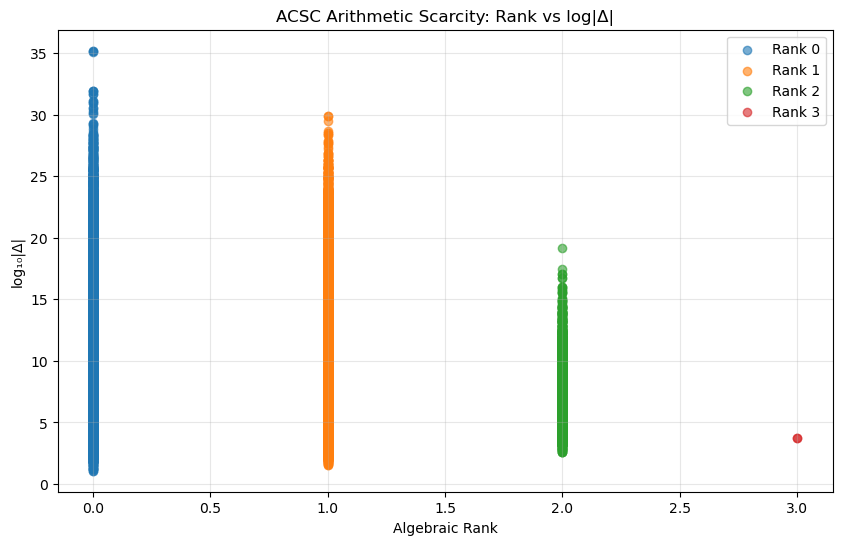


 ACSC analysis complete!
   → acsc_final_combined.csv (all data)
   → acsc_scarcity_plot.png (visual)
Ready for thesis tables/figures.


In [13]:
# acsc_final_summary.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=== ACSC Final Summary Analysis ===\n")

# Load both files
cremona = pd.read_csv("acsc_validation_cremona.csv")
lmfdb = pd.read_csv("acsc_validation_lmfdb.csv")

print(f"Cremona: {len(cremona):,} curves")
print(f"LMFDB:   {len(lmfdb):,} curves\n")

# Combine for overall statistics
df = pd.concat([cremona, lmfdb], ignore_index=True)

# Clean numeric columns
for col in ["sage_rank", "pari_2_selmer_rank", "pari_analytic_rank", "log_abs_delta"]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 1. Rank Distribution
print("Rank Distribution:")
print(df["sage_rank"].value_counts().sort_index())

# 2. Complexity-14 Pass Rate (your exact logic)
pass_rate = df["passes_complexity_14"].mean() * 100
print(f"\nComplexity-14 Pass Rate: {pass_rate:.2f}% "
      f"({df['passes_complexity_14'].sum():,} curves passed)")

# 3. Arithmetic Scarcity (log|Δ| vs Rank)
scarcity = df.groupby("sage_rank")["log_abs_delta"].mean().round(3)
print("\nArithmetic Scarcity (average log|Δ| by rank):")
print(scarcity)

# 4. Rank Consistency (Sage = PARI 2-Selmer = Analytic)
consistent = (
    (df["sage_rank"] == df["pari_2_selmer_rank"]) & 
    (df["sage_rank"] == df["pari_analytic_rank"])
).mean() * 100
print(f"\nSage/PARI Rank Consistency: {consistent:.1f}%")

# 5. Save enriched combined file
df.to_csv("acsc_final_combined.csv", index=False)
print("\nSaved full combined dataset → acsc_final_combined.csv")

# Quick plot: Rank vs log|Δ|
plt.figure(figsize=(10, 6))
for r in sorted(df["sage_rank"].dropna().unique()):
    subset = df[df["sage_rank"] == r]
    plt.scatter(subset["sage_rank"], subset["log_abs_delta"], alpha=0.6, label=f"Rank {r}")
plt.xlabel("Algebraic Rank")
plt.ylabel("log₁₀|Δ|")
plt.title("ACSC Arithmetic Scarcity: Rank vs log|Δ|")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("acsc_scarcity_plot.png")
plt.show()

print("\n ACSC analysis complete!")
print("   → acsc_final_combined.csv (all data)")
print("   → acsc_scarcity_plot.png (visual)")
print("Ready for thesis tables/figures.")